# Análisis Comparativo de Modelos Entrenados - Proyecto DFU

Este notebook permite cargar y evaluar de forma interactiva las métricas obtenidas por los diferentes modelos entrenados sobre la tarea de segmentación y clasificación de úlceras.

### 1. Configurar Entorno e Importar Librerías

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encontrar la raíz del repositorio
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Raíz del Repositorio: {REPO_ROOT}")

# Configurar estilo de visualización
sns.set_theme(style="whitegrid")

Raíz del Repositorio: /home/diego-villalba/Proyecto_DFU


### 2. Cargar Métricas de Evaluación de Modelos

In [2]:
metrics_csv = os.path.join(REPO_ROOT, "results", "tables", "dfutissue_metrics.csv")
if os.path.exists(metrics_csv):
    df = pd.read_csv(metrics_csv)
    print(f"Métricas cargadas exitosamente de {metrics_csv}.")
    display(df.head())
else:
    print(f"[-] No se encontró el archivo {metrics_csv}. Por favor ejecuta scripts/evaluate_models.py primero.")

Métricas cargadas exitosamente de /home/diego-villalba/Proyecto_DFU/results/tables/dfutissue_metrics.csv.


,image,model,dsc,iou,precision,recall,hd95,assd
0,img_001.png,MANet MiT-b3,0.984937,0.970404,0.985340,0.984942,1.0,0.576168
1,img_001.png,U-Net MiT-b3,0.985718,0.972200,0.976232,0.995944,1.0,0.443987
2,img_001.png,SegFormer MiT-b3,0.969978,0.942029,0.971350,0.970171,2.0,0.947737
3,img_001.png,ResUNet,0.994050,0.988181,0.992119,0.995988,1.0,0.197714
4,img_001.png,U-Net MobileNetV2,0.991780,0.983725,0.989371,0.994202,1.0,0.252762


### 3. Visualizar Distribución del Coeficiente Dice (DSC)

/tmp/ipykernel_54875/3207950250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="dsc", data=df, palette="Set2")


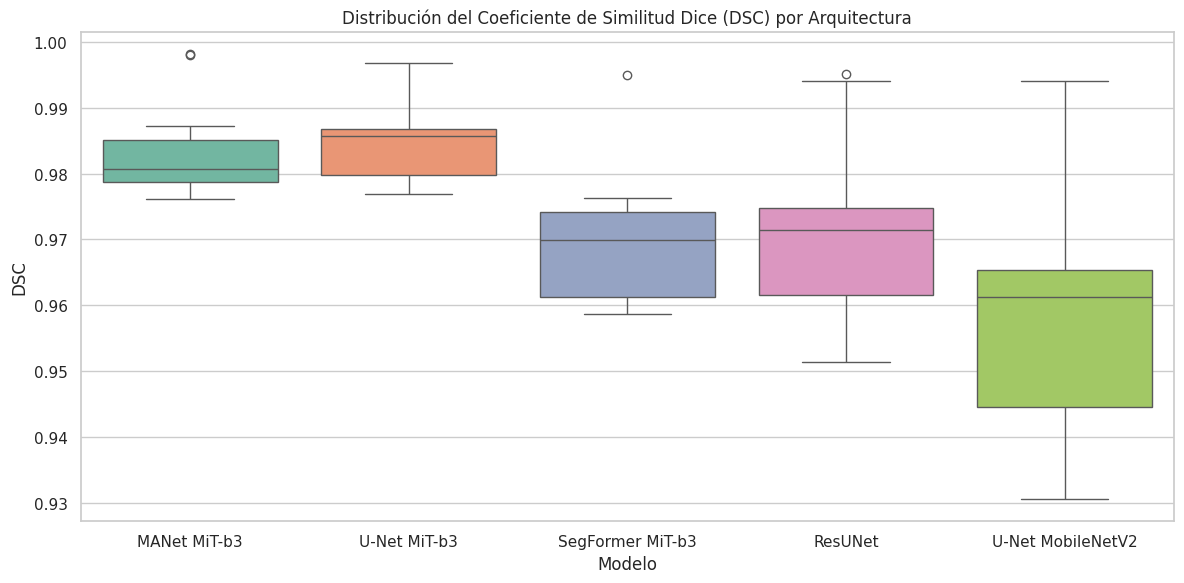

In [3]:
if 'df' in locals():
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="model", y="dsc", data=df, palette="Set2")
    plt.title("Distribución del Coeficiente de Similitud Dice (DSC) por Arquitectura")
    plt.xlabel("Modelo")
    plt.ylabel("DSC")
    plt.tight_layout()
    plt.show()

### 4. Analizar Hausdorff Distance (HD95)

/tmp/ipykernel_54875/3611916516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="hd95", data=df, palette="Set2")


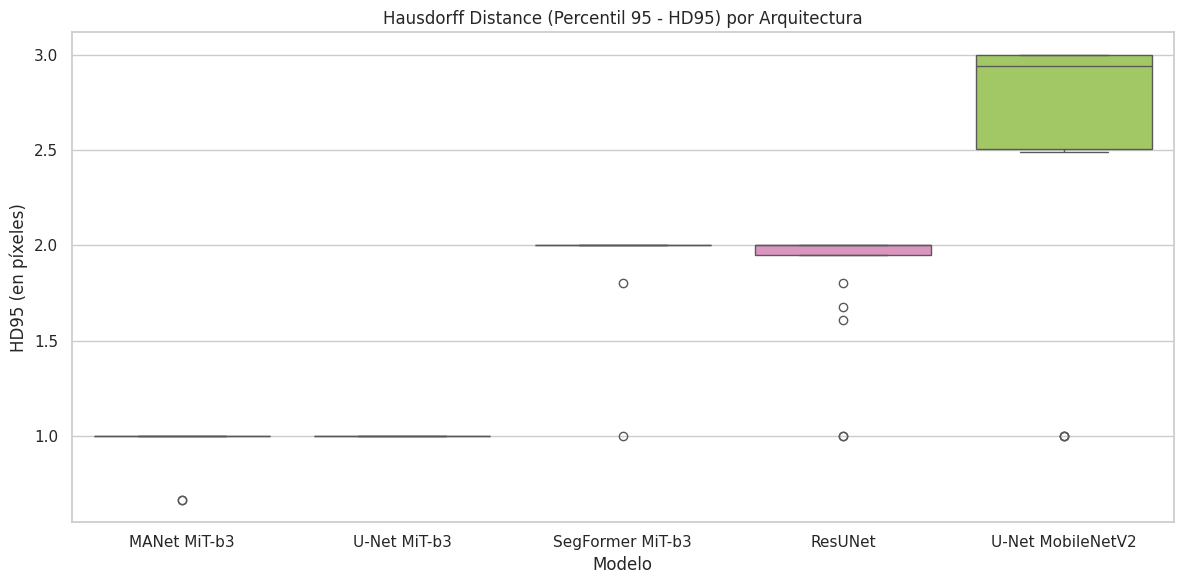

In [4]:
if 'df' in locals():
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="model", y="hd95", data=df, palette="Set2")
    plt.title("Hausdorff Distance (Percentil 95 - HD95) por Arquitectura")
    plt.xlabel("Modelo")
    plt.ylabel("HD95 (en píxeles)")
    plt.tight_layout()
    plt.show()

### 5. Ranking Promedio de Rendimiento

/tmp/ipykernel_54875/769217021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="rank", y="model", data=avg_rank, palette="Blues_r")


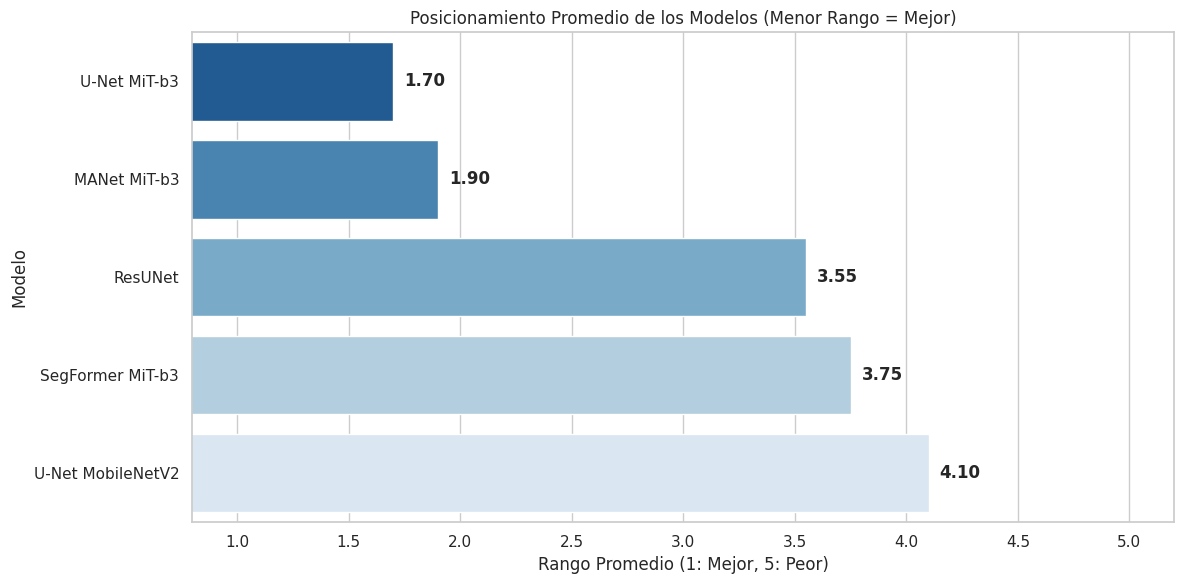

In [5]:
if 'df' in locals():
    # Calcular el rango para cada imagen
    df["rank"] = df.groupby("image")["dsc"].rank(ascending=False, method="min")
    avg_rank = df.groupby("model")["rank"].mean().reset_index().sort_values("rank")
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x="rank", y="model", data=avg_rank, palette="Blues_r")
    plt.title("Posicionamiento Promedio de los Modelos (Menor Rango = Mejor)")
    plt.xlabel("Rango Promedio (1: Mejor, 5: Peor)")
    plt.ylabel("Modelo")
    plt.xlim(0.8, 5.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.05, p.get_y() + p.get_height()/2.0, f'{width:.2f}', 
                 ha="left", va="center", fontweight='bold')
        
    plt.tight_layout()
    plt.show()